# 🛰️🔆 TKG Solar — Colab GPU Training (clone & run)

Tái lập huấn luyện **TKGSolarModel** (M1→M10) end-to-end *trực tiếp trên notebook*:
clone repo → cài deps → mount dữ liệu Drive → M1 pipeline → dựng model → **train** →
đánh giá → vẽ biểu đồ → lưu checkpoint. Mỗi bước phân tách bằng đường kẻ + công thức.

> **Trước khi chạy:** `Runtime → Change runtime type → GPU` (T4/A100). Chạy tuần tự từ trên xuống.

> ⚠️ Tái lập **cơ học/mã nguồn** (3 nguồn dữ liệu không cùng vị trí địa lý — faithful theo
> paper). "Aligned" = canh đồng hồ UTC, không phải ghép cặp vật lý. Xem `docs/assumptions.md`.

**Luồng:**
```
clone ─▶ deps ─▶ Drive data ─▶ M1(load→align→clean→split→clip→scale→window) ─▶ model ─▶ fit ─▶ eval ─▶ plot ─▶ save
```

<hr style="border:none;border-top:3px solid #d95f0e;margin:8px 0">
## 1 · Kiểm tra GPU

In [1]:
!nvidia-smi

Sun Jun  7 16:33:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   71C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

<hr style="border:none;border-top:3px solid #d95f0e;margin:8px 0">
## 2 · Lấy code (clone nhánh `init-project`)

Điền `GITHUB_USER` của bạn. Repo: **`tkg-solar-satellite-reasoning`**, nhánh `init-project`.

In [3]:
! git clone https://github.com/DucLong06/tkg-solar-satellite-reasoning.git
! cd tkg-solar-satellite-reasoning


fatal: destination path 'tkg-solar-satellite-reasoning' already exists and is not an empty directory.


<hr style="border:none;border-top:3px solid #d95f0e;margin:8px 0">
## 3 · Cài dependencies

Colab đã có **torch CUDA** sẵn — chỉ cài thêm package còn thiếu (KHÔNG dùng `uv sync`).

In [4]:
import torch
print('torch', torch.__version__, '| CUDA available:', torch.cuda.is_available())
!pip install -q timm torch_geometric h5py scikit-learn pyyaml tqdm pathlib


torch 2.11.0+cu128 | CUDA available: True


<hr style="border:none;border-top:3px solid #d95f0e;margin:8px 0">
## 4 · Dữ liệu (mount Google Drive)

Upload 3 nguồn lên Drive theo cấu trúc dưới, rồi điền `DATA_ROOT`:
```
<DATA_ROOT>/
  opsd/time_series_15min_singleindex.csv
  nsrdb/vietnam_2016.h5
  himawari/frames.h5
```

In [5]:
import pathlib
from google.colab import drive
drive.mount('/content/drive')

# <-- ĐIỀN đường dẫn thư mục dữ liệu trên Drive của bạn:
DATA_ROOT = '/content/drive/MyDrive/tkg-solar-data'

opsd_path    = f'{DATA_ROOT}/opsd/time_series_15min_singleindex.csv'
nsrdb_path   = f'{DATA_ROOT}/nsrdb/vietnam_2016.h5'
himawari_dir = f'{DATA_ROOT}/himawari'

for p in (opsd_path, nsrdb_path, himawari_dir):
    print(('OK  ' if pathlib.Path(p).exists() else 'MISSING '), p)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
OK   /content/drive/MyDrive/tkg-solar-data/opsd/time_series_15min_singleindex.csv
OK   /content/drive/MyDrive/tkg-solar-data/nsrdb/vietnam_2016.h5
OK   /content/drive/MyDrive/tkg-solar-data/himawari


<hr style="border:none;border-top:3px solid #d95f0e;margin:8px 0">
## 5 · Config (paper) + thiết bị

Nạp `paper_config.yaml` (ViT-B/16, 200 epochs, Table 5) → đặt `device=cuda`.

> ⚠️ **min_steps.** Paper config dùng `min_steps=2000` (cần ~tuần dữ liệu). Nếu bạn chỉ
> upload cửa sổ Himawari 3 ngày (~184 bước aligned) thì **hạ `min_steps`** xuống ~150,
> nếu không cổng giao nhau (Bước 6) sẽ báo `EmptyOverlapError`.

In [6]:
!cd tkg-solar-satellite-reasoning && git checkout init-project

Already on 'init-project'
Your branch is up to date with 'origin/init-project'.


In [7]:
%cd tkg-solar-satellite-reasoning

/content/tkg-solar-satellite-reasoning


In [8]:
import os
# Chống phân mảnh bộ nhớ CUDA (đặt trước khi model lên GPU).
os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')

from src.training.config import Config
from src.common.seeding import seed_everything
from src.common.shapes import EMBED_DIM, FUSION_DIM, HORIZON_MINUTES, N_HORIZONS

cfg = Config.from_yaml('configs/paper_config.yaml')
cfg.device = 'cuda' if torch.cuda.is_available() else 'cpu'

# min_steps = ngưỡng TỐI THIỂU số bước aligned (cổng an toàn). paper=2000 (cần ~tuần data).
# Himawari 3 ngày chỉ ~184 bước -> hạ 150. Để 150 vẫn an toàn với data dài hơn.
cfg.min_steps = 150

# batch_size: satellite encoder chạy ViT trên TỪNG frame -> batch hiệu dụng = batch_size * k.
# paper=64 => 64*12=768 ảnh 224x224/batch -> OOM trên T4 16GB. Hạ 8 (8*12=96 ảnh) cho vừa.
# GPU lớn (A100 40GB) có thể nâng 32-64. Hoặc bật cfg.freeze_backbone=True để tiết kiệm thêm.
cfg.batch_size = 8
# cfg.freeze_backbone = True   # đóng băng ViT -> nhẹ & nhanh hơn (giảm độ trung thực 1 chút)
# cfg.epochs = 200

seed_everything(cfg.seed)
print('device     :', cfg.device)
print('backbone   :', cfg.sat_backbone, '| img', cfg.img_size, '| freeze', cfg.freeze_backbone)
print('epochs     :', cfg.epochs, '| batch', cfg.batch_size, '| lr', cfg.lr)
print('min_steps  :', cfg.min_steps, '| k', cfg.k, '| effective ViT batch', cfg.batch_size*cfg.k)

device     : cuda
backbone   : vit_base_patch16_224 | img 224 | freeze False
epochs     : 200 | batch 8 | lr 0.0001
min_steps  : 150 | k 12 | effective ViT batch 96


<hr style="border:none;border-top:3px solid #d95f0e;margin:8px 0">
## 6 · M1 data pipeline

`DataPipeline.load` chạy đúng chuỗi: **load → align(10-min grid) → clean → split(70/15/15)
→ clip(μ±5σ train-only) → scale(Min-Max train-only) → window → DataLoader**. Chi tiết +
công thức từng bước xem `notebooks/data_pipeline_walkthrough.ipynb`.

Cửa sổ bắt đầu hợp lệ: $i \in \{0,\dots,T-k-\max_h h\}$; target tại $(i+k-1)+h$, $h\in(1,3,6)$.

In [9]:
from src.data_pipeline import DataPipeline

splits = DataPipeline.load(
    opsd_path, nsrdb_path, himawari_dir,
    k=cfg.k, batch_size=cfg.batch_size, img_size=cfg.img_size,
    min_steps=cfg.min_steps, train_frac=cfg.train_frac, val_frac=cfg.val_frac,
    cache_dir=cfg.cache_dir, scaler_out=cfg.scaler_out,
)
for k_, v_ in splits.meta.items():
    print(f'  {k_:18s}: {v_}')

  n_meteo_features  : 7
  sat_channels      : 1
  img_size          : 224
  k                 : 12
  n_steps           : 184
  n_train_windows   : 111
  n_val_windows     : 11
  n_test_windows    : 11


<hr style="border:none;border-top:3px solid #d95f0e;margin:8px 0">
## 7 · Dựng model (TKGSolarModel)

Hợp đồng chiều (paper Table 5): mọi encoder xuất **128-dim**; fusion nối 3 nhánh:

$$\mathbf{z} = [\,F_{sat}\ \Vert\ H_{met}\ \Vert\ H_{graph}\,] \in \mathbb{R}^{384},\qquad \hat{\mathbf{y}} = \text{MLP}(\mathbf{z}) \in \mathbb{R}^{3}$$

trong đó $F_{sat}$ = ViT vệ tinh, $H_{met}$ = GRU+Transformer khí tượng, $H_{graph}$ = GAT+Fourier trên TKG động.

In [10]:
from src.fusion_predictor.tkg_solar_model import TKGSolarModel

model = TKGSolarModel.from_config(cfg)
n_params = sum(p.numel() for p in model.parameters())
n_train  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'FUSION_DIM = {FUSION_DIM} = 3 x {EMBED_DIM}')
print(f'tham số    : {n_params:,} (trainable {n_train:,})')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


FUSION_DIM = 384 = 3 x 128
tham số    : 86,918,345 (trainable 86,918,345)


<hr style="border:none;border-top:3px solid #d95f0e;margin:8px 0">
## 8 · Huấn luyện (train)

`fit` (`src/training/train_loop.py`): Adam + **MSE trên target đã scale**; early-stop
theo **val-MAE ở đơn vị gốc** (inverse-transform); lưu checkpoint tốt nhất; grad-clip.

**Hàm mất mát** (scaled, $B$ batch, $H{=}3$ horizon):
$$\mathcal{L} = \frac{1}{B\,H}\sum_{b=1}^{B}\sum_{h=1}^{H}\big(\hat{y}'_{b,h} - y'_{b,h}\big)^2$$

**Tiêu chí early-stop** (đơn vị gốc, qua inverse-scale $\text{inv}(\cdot)$):
$$\text{val-MAE} = \frac{1}{N\,H}\sum_{n,h}\big|\,\text{inv}(\hat{y}'_{n,h}) - \text{inv}(y'_{n,h})\,\big|$$

In [11]:
import gc
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

from src.training.train_loop import fit

history = fit(model, splits, cfg, verbose=True)
print('\nbest val-MAE :', round(history['best_val_mae'], 5))
print('checkpoint   :', history['best_checkpoint'])

epoch 1/200:   0%|          | 0/14 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: Memory Efficient attention defaults to a non-deterministic algorithm. To explicitly enable determinism call torch.use_deterministic_algorithms(True, warn_only=False). (Triggered internally at /pytorch/aten/src/ATen/native/transformers/cuda/attention_backward.cu:900.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


epoch 1: train_loss=0.08973 val_mae=34.87170


epoch 2: train_loss=0.06840 val_mae=18.97862


epoch 3: train_loss=0.03776 val_mae=24.17721


epoch 4: train_loss=0.02304 val_mae=11.67505


...

epoch 20: train_loss=0.00717 val_mae=19.99022


epoch 21: train_loss=0.00607 val_mae=22.62860


epoch 22: train_loss=0.00773 val_mae=24.84827


epoch 23: train_loss=0.00923 val_mae=17.23976


epoch 24: train_loss=0.01141 val_mae=23.15506
early stop at epoch 24 (best val_mae=11.67505)

best val-MAE : 11.67505
checkpoint   : checkpoints/best_full.pt


<hr style="border:none;border-top:3px solid #d95f0e;margin:8px 0">
## 9 · Đường học (train loss & val MAE)

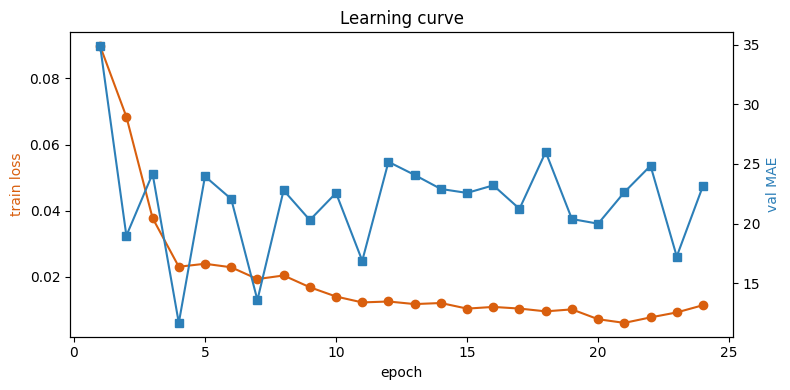

In [12]:
import matplotlib.pyplot as plt
ep = range(1, len(history['train_loss'])+1)
fig, ax1 = plt.subplots(figsize=(8,4))
ax1.plot(ep, history['train_loss'], 'o-', color='#d95f0e', label='train loss (MSE, scaled)')
ax1.set_xlabel('epoch'); ax1.set_ylabel('train loss', color='#d95f0e')
ax2 = ax1.twinx()
ax2.plot(ep, history['val_mae'], 's-', color='#2c7fb8', label='val MAE (orig units)')
ax2.set_ylabel('val MAE', color='#2c7fb8')
plt.title('Learning curve'); fig.tight_layout(); plt.show()

<hr style="border:none;border-top:3px solid #d95f0e;margin:8px 0">
## 10 · Đánh giá test (MAE / RMSE / MAPE theo horizon)

Metric tính ở **đơn vị gốc** (`src/metrics/`). MAPE chỉ trên mẫu ban ngày
$|y|\ge\texttt{mape\_min\_value}$ (PV ban đêm ≈ 0 → MAPE bùng nổ; loại có báo tỉ lệ).

$$\text{MAE}=\tfrac1N\sum|y-\hat y|,\quad \text{RMSE}=\sqrt{\tfrac1N\sum(y-\hat y)^2},\quad \text{MAPE}=\tfrac{100}{|\mathcal D|}\!\!\sum_{n\in\mathcal D}\!\Big|\tfrac{y_n-\hat y_n}{y_n}\Big|$$

In [13]:
from src.training.train_loop import predict_loader
from src.metrics.regression_metrics import compute_per_horizon

yt, yp = predict_loader(model, splits.test_loader, cfg.device)
yt = splits.scalers.inverse_pv(yt.numpy()); yp = splits.scalers.inverse_pv(yp.numpy())
per = compute_per_horizon(yt, yp, HORIZON_MINUTES, cfg.mape_min_value)

print(f"{'horizon':>10} | {'MAE':>9} | {'RMSE':>9} | {'MAPE %':>9}")
print('-'*46)
for lab in ['overall', *[f'{m}min' for m in HORIZON_MINUTES]]:
    m = per[lab]
    print(f"{lab:>10} | {m['mae']:9.4f} | {m['rmse']:9.4f} | {m['mape']:9.2f}")

   horizon |       MAE |      RMSE |    MAPE %
----------------------------------------------
   overall |   38.9710 |   49.3070 |     10.99
     10min |    8.9593 |   12.0027 |      2.70
     30min |   35.6396 |   38.8182 |     10.46
     60min |   72.3141 |   75.1174 |     19.79


<hr style="border:none;border-top:3px solid #d95f0e;margin:8px 0">
## 11 · Dự báo vs thực tế (mỗi horizon)

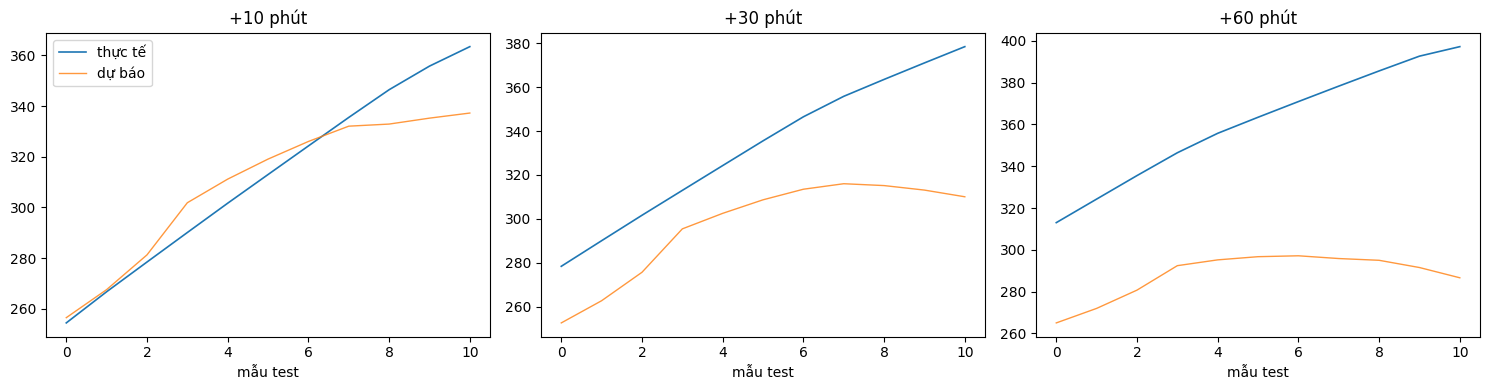

In [14]:
import numpy as np
fig, axes = plt.subplots(1, N_HORIZONS, figsize=(15, 4))
for j, mins in enumerate(HORIZON_MINUTES):
    ax = axes[j]
    ax.plot(yt[:, j], label='thực tế', lw=1.2)
    ax.plot(yp[:, j], label='dự báo', lw=1.0, alpha=.8)
    ax.set_title(f'+{mins} phút'); ax.set_xlabel('mẫu test')
    if j == 0: ax.legend()
plt.tight_layout(); plt.show()

<hr style="border:none;border-top:3px solid #d95f0e;margin:8px 0">
## 12 · Lưu checkpoint + scaler về Drive (tùy chọn)

`fit` đã lưu best checkpoint cục bộ; copy sang Drive để giữ lại sau khi runtime tắt.

In [16]:
import shutil
SAVE_DIR = f'{DATA_ROOT}/outputs'
pathlib.Path(SAVE_DIR).mkdir(parents=True, exist_ok=True)
shutil.copy(history['best_checkpoint'], SAVE_DIR)
if pathlib.Path(cfg.scaler_out).exists():
    shutil.copy(cfg.scaler_out, SAVE_DIR)
cfg.save(f'{SAVE_DIR}/resolved_config.yaml')
print('Đã lưu vào', SAVE_DIR)

Đã lưu vào /content/drive/MyDrive/tkg-solar-data/outputs


<hr style="border:none;border-top:3px solid #d95f0e;margin:8px 0">
## 13 · Benchmark 5 mô hình — chứng minh trọng tâm paper (Table 6)

Đây mới là phần **chứng minh mô hình đề xuất vượt trội**: train **cả 5 mô hình**
(LSTM · GRU · Transformer · Temporal-GNN · **Proposed**) trên **cùng data / cùng
split / cùng seed khởi tạo** rồi so MAE/RMSE/MAPE. Mục tiêu paper: Proposed có MAE
THẤP NHẤT.

$$\text{ordering target:}\quad \text{MAE}_{Proposed} < \text{MAE}_{Temporal\text{-}GNN} < \text{MAE}_{Transformer} < \text{MAE}_{GRU} < \text{MAE}_{LSTM}$$

> ⚠️ **Nặng:** 5 mô hình × epochs. Đặt `bcfg.epochs` nhỏ để thử nhanh, tăng lại cho kết quả cuối.
> ⚠️ **Caveat dữ liệu:** trên cửa sổ data ngắn (vài ngày → ~trăm cửa sổ train), mô hình
> Proposed 12M tham số **overfit** và có thể KHÔNG thắng baseline. Muốn benchmark có ý
> nghĩa cần dữ liệu dài hơn (xem Bước 15).

In [ ]:
import copy, gc
from src.common.seeding import seed_everything
from src.evaluation.baseline_models import build_baseline
from src.evaluation.benchmark_table import build_benchmark, relative_ordering, PAPER_TABLE6
from src.lstm_baseline.lstm_forecaster import LSTMForecaster
from src.training.evaluate import evaluate_model
from src.training.train_loop import fit

bcfg = copy.copy(cfg)
# bcfg.epochs = 50   # <-- bỏ comment để chạy nhanh khi thử; tăng lại cho kết quả cuối

MODELS = ["LSTM", "GRU", "Transformer", "Temporal-GNN", "Proposed"]
def build_model_by_name(name):
    if name == "LSTM":     return LSTMForecaster(hidden_dim=bcfg.embed_dim, dropout=bcfg.dropout)
    if name == "Proposed": return TKGSolarModel.from_config(bcfg)
    return build_baseline(name, bcfg)

results = {}
for name in MODELS:
    print(f"=== training {name} ===")
    seed_everything(bcfg.seed)              # cùng seed khởi tạo -> so sánh công bằng
    model_b = build_model_by_name(name)
    fit(model_b, splits, bcfg, verbose=False)
    metrics = evaluate_model(model_b, splits.test_loader, splits.scalers, bcfg.device, bcfg.mape_min_value)
    results[name] = metrics["overall"]
    print(f"  {name:13s} MAE={metrics['overall']['mae']:.4f} "
          f"RMSE={metrics['overall']['rmse']:.4f} MAPE={metrics['overall']['mape']:.2f}%")
    del model_b; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

<hr style="border:none;border-top:3px solid #d95f0e;margin:8px 0">
### 13.1 · Bảng so sánh + thứ tự + biểu đồ cột MAE

In [ ]:
import matplotlib.pyplot as plt

print(build_benchmark(results))
order = relative_ordering(results)
print("\nThứ tự (tốt→kém theo MAE):", " < ".join(order))
won = order[0] == "Proposed"
print("=> Proposed THẮNG (MAE thấp nhất)?" , "✅ CÓ" if won else "❌ CHƯA (cần thêm dữ liệu/epoch)")

# Biểu đồ cột MAE (đơn vị gốc) theo mô hình — Proposed tô khác màu.
names = MODELS
maes  = [results[n]['mae'] for n in names]
colors = ['#d95f0e' if n == 'Proposed' else '#9ecae1' for n in names]
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(names, maes, color=colors, edgecolor='black', linewidth=.6)
ax.set_ylabel('MAE (đơn vị gốc, thấp = tốt)')
ax.set_title('Benchmark 5 mô hình — MAE trên test (cùng split/seed)')
for b, v in zip(bars, maes):
    ax.text(b.get_x()+b.get_width()/2, v, f'{v:.2f}', ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

<hr style="border:none;border-top:3px solid #d95f0e;margin:8px 0">
## 14 · (tùy chọn) Chạy `scripts/run_baselines.py` → xuất file report

Script làm đúng việc trên nhưng **ghi ra file** `plans/reports/benchmark-table6-comparison-report.md`
(có cột so với paper Table 6). Cần sửa config cho vừa T4 + data ngắn trước khi chạy.

> Nặng (5 model × epochs). Hạ `epochs` trong `paper_config.yaml` nếu chỉ muốn thử.

In [ ]:
# Sửa config cho vừa T4 16GB + data ngắn (giống override trong notebook).
!sed -i -e 's/^device: cpu/device: cuda/' \
        -e 's/^min_steps: 2000/min_steps: 150/' \
        -e 's/^batch_size: 64/batch_size: 8/' configs/paper_config.yaml
# (tùy chọn) chạy nhanh: !sed -i 's/^epochs: 200/epochs: 50/' configs/paper_config.yaml

!python scripts/run_baselines.py --config configs/paper_config.yaml
print('\n================ REPORT ================\n')
!cat plans/reports/benchmark-table6-comparison-report.md

<hr style="border:none;border-top:3px solid #d95f0e;margin:8px 0">
## 15 · Kế hoạch lấy thêm dữ liệu Himawari (để benchmark có ý nghĩa)

**Vì sao cần:** Proposed có **12M tham số**; với cửa sổ 3 ngày (~110 cửa sổ train) nó
overfit → benchmark không phản ánh đúng. Cần nới cửa sổ Himawari để có **≥ 2000 bước
aligned** (đủ cho `min_steps` của paper).

**Ràng buộc khớp dữ liệu:** NSRDB (`vietnam_2016.h5`) phủ **cả năm 2016**, OPSD phủ
2014–2020 → **Himawari là nút thắt**. Himawari-8 có sẵn 2015-07 … 2022, nên kéo thêm
ngày **trong năm 2016** (vd tháng 6–8/2016) để trùng NSRDB.

**Ước lượng:** daytime UTC 0–9h, cadence 10 phút → ~60 frame/ngày. Cần ~**34 ngày** để
đạt 2000 bước → kéo **40–60 ngày** cho dư.

```bash
# 1 lệnh duy nhất: tải B03 từ NOAA AWS (no-sign) + crop ROI Vietnam + gộp -> frames.h5
#    (incremental: tải -> giải nén -> resample -> xoá raw, nên nhẹ đĩa nhưng CHẬM/long-lead)
pip install -q satpy s3fs h5netcdf bottleneck   # phụ thuộc đọc HSD
python scripts/build_himawari_frames.py --start 2016-06-01 --end 2016-07-31 --size 64
#   -> ghi đè data/himawari/frames.h5 (M1 ưu tiên frames.h5 hơn synthetic)
```

**Sau khi có data dài:**
1. Để `cfg.min_steps` cao lại (vd 1500–2000) — bỏ override 150.
2. `cfg.batch_size`: giữ 8 trên T4, hoặc nâng nếu dùng A100.
3. Chạy lại **Bước 13** (benchmark 5 model) → giờ ordering mới đáng tin.

> ⚠️ Bước này tốn thời gian (hàng nghìn lần tải segment). Nên chạy **sớm**, có thể trên
> máy SSH GPU rồi upload `frames.h5` lên Drive thay vì kéo trực tiếp trong Colab.
> Disk Colab free ~vài chục GB là đủ vì xử lý incremental.